In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df=pd.read_csv('Loan_Default.csv')
df=df.drop(columns=['LoanID'])

# EDA


In [ ]:
df.sample(5)

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
166237,53,96278,191689,766,49,3,17.43,36,0.67,PhD,Part-time,Single,No,Yes,Auto,Yes,0
186816,60,78067,61856,365,107,2,9.48,48,0.62,Master's,Unemployed,Single,Yes,Yes,Business,Yes,0
150588,40,142022,20921,337,59,2,15.19,48,0.12,Bachelor's,Part-time,Married,Yes,No,Auto,No,0
234187,51,143980,33935,523,49,3,13.37,36,0.38,Bachelor's,Self-employed,Single,No,No,Business,No,1
40569,40,144242,215117,748,20,2,4.87,60,0.86,High School,Unemployed,Married,No,Yes,Business,No,0


In [ ]:
df.shape

(255347, 17)

In [ ]:
df.isnull().mean()*100

Age               0.0
Income            0.0
LoanAmount        0.0
CreditScore       0.0
MonthsEmployed    0.0
NumCreditLines    0.0
InterestRate      0.0
LoanTerm          0.0
DTIRatio          0.0
Education         0.0
EmploymentType    0.0
MaritalStatus     0.0
HasMortgage       0.0
HasDependents     0.0
LoanPurpose       0.0
HasCoSigner       0.0
Default           0.0
dtype: float64

Text(0.5, 1.0, 'Age vs Default')

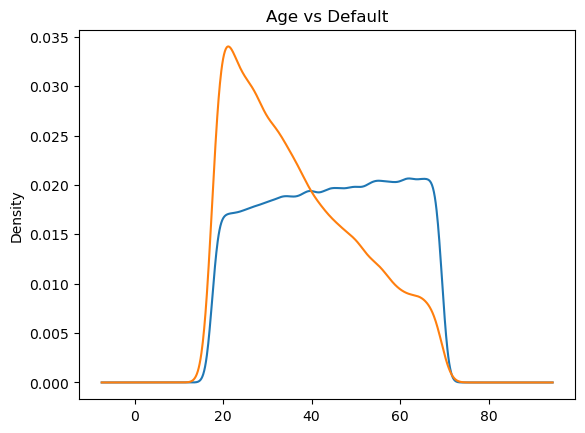

In [ ]:
df[df['Default']==0]['Age'].plot(kind='kde', label='Default 0')
df[df['Default']==1]['Age'].plot(kind='kde', label='Default 1')
plt.title('Age vs Default')

## Younger people tends to default more on Loan

Text(0.5, 1.0, 'Income vs Default')

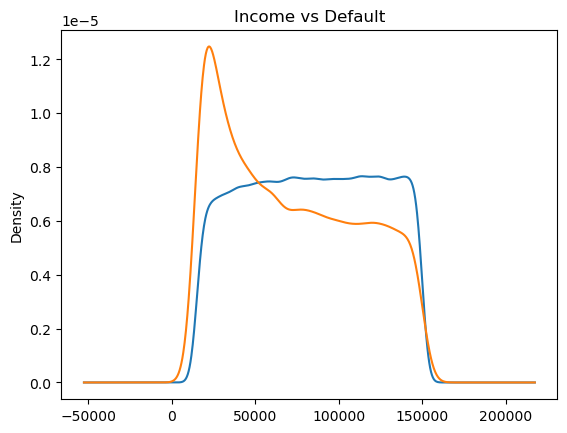

In [ ]:
df[df['Default']==0]['Income'].plot(kind='kde', label='Default 0')
df[df['Default']==1]['Income'].plot(kind='kde', label='Default 1')
plt.title("Income vs Default")

## People with low Income tends to deafult more.

Text(0.5, 1.0, 'LoanAmount vs Default')

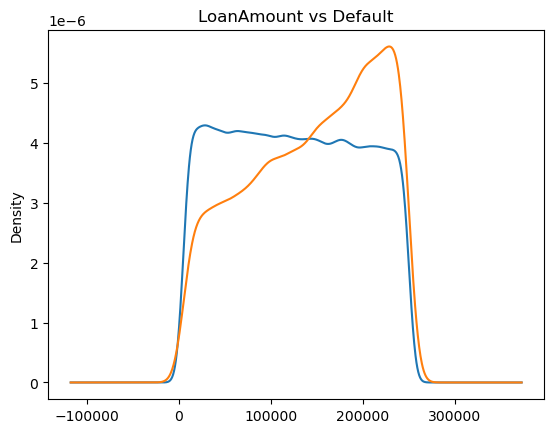

In [ ]:
df[df['Default']==0]['LoanAmount'].plot(kind='kde', label='Default 0')
df[df['Default']==1]['LoanAmount'].plot(kind='kde', label='Default 1')
plt.title("LoanAmount vs Default")

## Loans with Higher Loan amount are defaulted more

Text(0.5, 1.0, 'CreditScore vs Default')

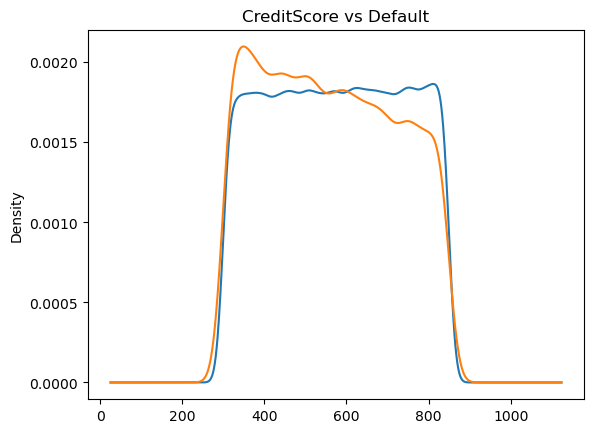

In [ ]:
df[df['Default']==0]['CreditScore'].plot(kind='kde', label='Default 0')
df[df['Default']==1]['CreditScore'].plot(kind='kde', label='Default 1')
plt.title("CreditScore vs Default")

## High credit score ensures safety of return.

Text(0.5, 1.0, 'InterestRate vs Default')

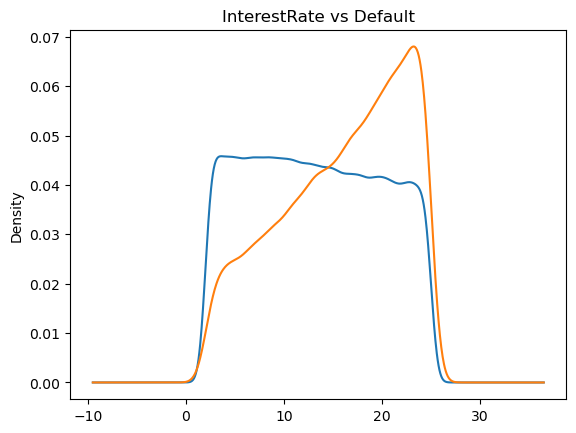

In [ ]:
df[df['Default']==0]['InterestRate'].plot(kind='kde', label='Default 0')
df[df['Default']==1]['InterestRate'].plot(kind='kde', label='Default 1')
plt.title("InterestRate vs Default")

# Categorical Columns EDA

## Loans with higer interest rate are defaulted more often.

Text(0.5, 1.0, 'Education type vs Default')

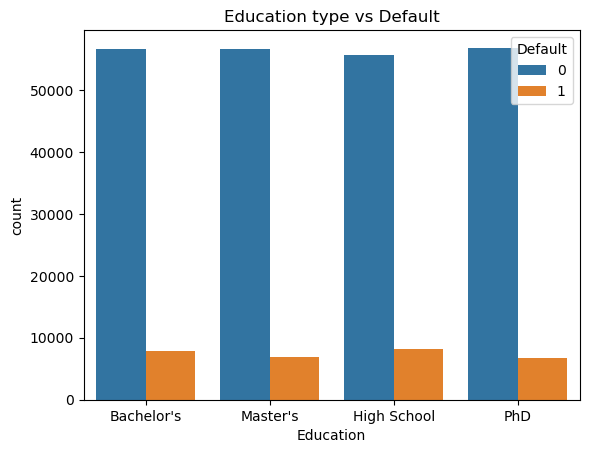

In [ ]:
sns.countplot(x='Education',hue='Default',data=df)
plt.title("Education type vs Default")

Text(0.5, 1.0, 'Employment Type vs Default')

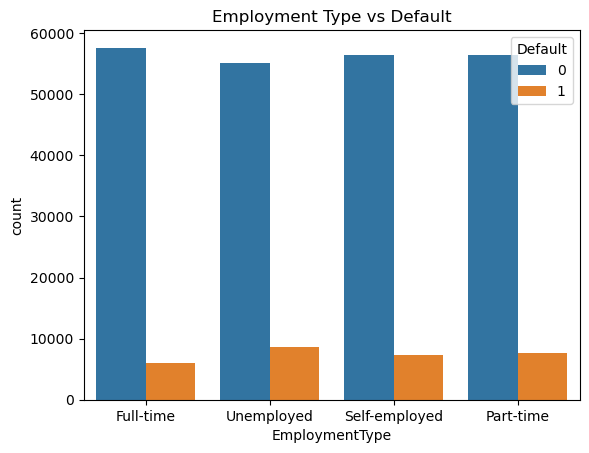

In [ ]:
sns.countplot(x='EmploymentType',hue='Default',data=df)
plt.title("Employment Type vs Default")

Text(0.5, 1.0, 'Marital Status vs Default')

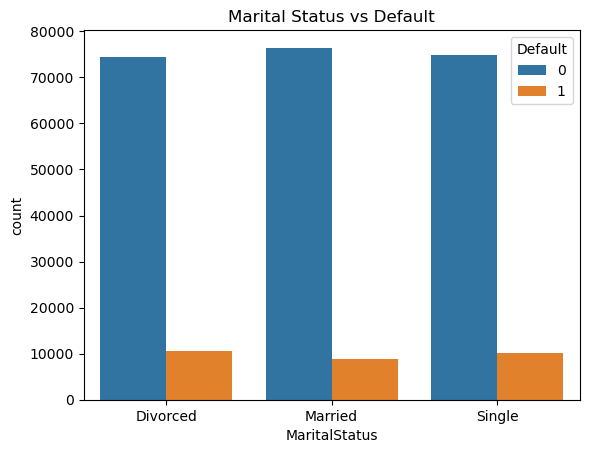

In [ ]:
sns.countplot(x='MaritalStatus',hue='Default',data=df)
plt.title("Marital Status vs Default")

Text(0.5, 1.0, 'HasMortgage vs Default')

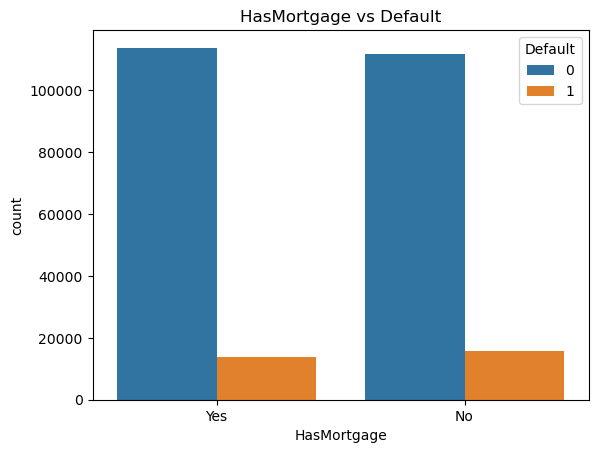

In [ ]:
sns.countplot(x='HasMortgage',hue='Default',data=df)
plt.title("HasMortgage vs Default")

In [ ]:
df['NumCreditLines'].value_counts()

df['Education'] = df['Education'].replace({
    "Bachelor's": "Bachelors"
})
df['Education'] = df['Education'].replace({
    "Master's": "Masters"
})
df['Education'].value_counts()

Education
Bachelors      64366
High School    63903
Masters        63541
PhD            63537
Name: count, dtype: int64

In [ ]:
df['LoanTerm'].value_counts()

LoanTerm
48    51166
60    51154
36    51061
24    51009
12    50957
Name: count, dtype: int64

In [ ]:
df['LoanPurpose'].value_counts()

LoanPurpose
Business     51298
Home         51286
Education    51005
Other        50914
Auto         50844
Name: count, dtype: int64

In [ ]:
num_cols=['Age','Income','LoanAmount','CreditScore','MonthsEmployed','NumCreditLines','InterestRate','LoanTerm','DTIRatio']
ord_cols=['Education']
cat_cols=['EmploymentType','MaritalStatus','HasMortgage','HasDependents','LoanPurpose','HasCoSigner']

In [ ]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

In [ ]:
num_pipeline=Pipeline([
    ('imputer',SimpleImputer()),
    ('Scalar',StandardScaler())
])

In [ ]:
ord_pipeline=Pipeline([
    ('ordinal',OrdinalEncoder(categories=[['High School','Bachelors','Masters','PhD']]))
])

In [ ]:
cat_pipeline=Pipeline([
    ('categorical',OneHotEncoder(sparse_output=False,dtype=int,drop='first'))
])

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    # "SVM": SVC(probability=True)
    # "KNN": KNeighborsClassifier(n_neighbors=5)
}

In [ ]:
transformer=ColumnTransformer(
    transformers=[
        ('tnf1',num_pipeline,num_cols),
        ('tnf2',ord_pipeline,ord_cols),
        ('tnf3',cat_pipeline,cat_cols),
    ]
)

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(df.drop(columns=['Default']),df['Default'],test_size=0.25)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

for name, model in models.items():

    pipe = Pipeline([
        ('preprocessing', transformer),
        ('model', model)
    ])

    pipe.fit(x_train, y_train)
    pred = pipe.predict(x_test)
    acc = accuracy_score(y_test, pred)

    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    try:
        prob = pipe.predict_proba(x_test)[:,1]
        roc = roc_auc_score(y_test, prob)
    except:
        roc = "Not Available"
    print("="*40)
    print("Model:", name)
    print("="*40)
    print("Accuracy:", acc)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)
    print("ROC-AUC:", roc)
    print("\n")

Model: Logistic Regression
Accuracy: 0.6755329981045475
Precision: 0.21739685783624985
Recall: 0.6864748588330196
F1 Score: 0.33021827000808407
ROC-AUC: 0.7444165741059383


Model: Decision Tree
Accuracy: 0.8019487131287498
Precision: 0.19500761748505802
Recall: 0.22371605270233935
F1 Score: 0.20837768455325278
ROC-AUC: 0.550961556555606


Model: Random Forest
Accuracy: 0.8849726647555493
Precision: 0.6107226107226107
Recall: 0.035224522721161604
F1 Score: 0.06660734714630737
ROC-AUC: 0.7259608811018214


